In [12]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

In [5]:
COLUNAS_REMOCAO = ["FID", "PAT", "MAT", "SEX", "PHENOTYPE"]
fenotipo = pd.read_csv('banco_fenotipos_conformal.csv')
caminho = ('Banco Genetico Imputado LD')
df_completo = None
for arquivo in os.listdir(caminho):
    if arquivo.endswith('.raw'):
        df_gen = pd.read_csv(f'{caminho}/{arquivo}',sep='\s+')
        df_gen = df_gen.drop(columns=COLUNAS_REMOCAO)
        if df_completo is None:
            df_completo = df_gen
        else:
            df_completo = pd.merge(left=df_completo,right=df_gen,on='IID',how='inner')

df_final = pd.merge(left=fenotipo,right=df_completo,left_on='samplefilename',right_on='IID',how='inner')
df_final = df_final.dropna(subset=['diabetes2'])


<>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\mateu\AppData\Local\Temp\ipykernel_14216\1993506937.py:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df_gen = pd.read_csv(f'{caminho}/{arquivo}',sep='\s+')


In [6]:
frequencias_porcentagem = (df_completo.isin([1, 2]).sum() / len(df_completo)).round(2).to_dict()
colunas_20 = {c: frequencias_porcentagem[c]for c in frequencias_porcentagem.keys() if frequencias_porcentagem[c] < 0.2}

In [46]:
X20 = df_final[colunas_20.keys()]
X20 = X.drop(columns=['IID'])
y20 = df_final['diabetes2']

KeyError: "['IID'] not found in axis"

In [ ]:
modelo_rf_20 = RandomForestClassifier(n_estimators=200, n_jobs=5, max_features=0.3, oob_score=True, class_weight='balanced')

modelo_rf_20.fit(X20, y20)

In [34]:
thr20 = 0.5
y_probs20 = modelo_rf_20.oob_decision_function_[:,1]
y_pred20 = y_probs20 > thr20

precision_recall_fscore_support(y20,y_pred20

C:\Users\mateu\OneDrive\Documentos\GitHub\Genetica\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


(array([0.84658298, 0.        ]),
 array([1., 0.]),
 array([0.91691843, 0.        ]),
 array([607, 110]))

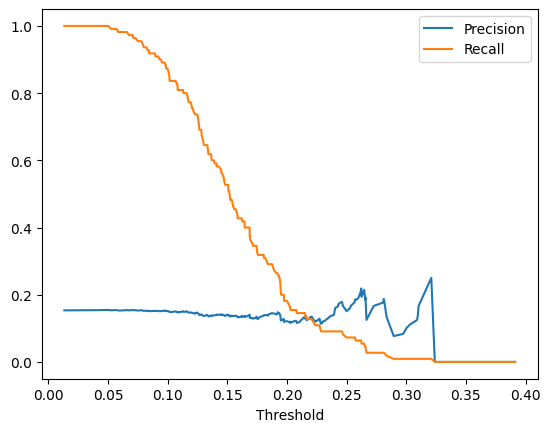

In [35]:
precisions, recalls, thresholds = precision_recall_curve(y, y_probs)
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.show()

In [7]:
colunas_para_ignorar = ['glicose_mg_dl', 'IID', 'samplefilename','diabetes2','HOMA_IR','medDM_bioq']


X = df_final.drop(columns=colunas_para_ignorar, errors='ignore')
y = df_final['diabetes2']

modelo_rf = RandomForestClassifier(n_estimators=200 n_jobs=5, max_features=0.3, oob_score=True, class_weight = 'balanced')
colunas_categoricas = ['fumo', 'raca_cor', 'conjugal3', 'trabalho2', 'bebem2']

X_arrumado = pd.get_dummies(X, columns=colunas_categoricas, drop_first=True, dtype=int)

In [8]:
modelo_rf.fit(X_arrumado,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.3
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [14]:
thr = 0.3
y_probs = modelo_rf.oob_decision_function_[:,1]
y_pred = y_probs > thr

precision_recall_fscore_support(y,y_pred)

(array([0.8757764, 0.4109589]),
 array([0.9291598 , 0.27272727]),
 array([0.90167866, 0.32786885]),
 array([607, 110]))

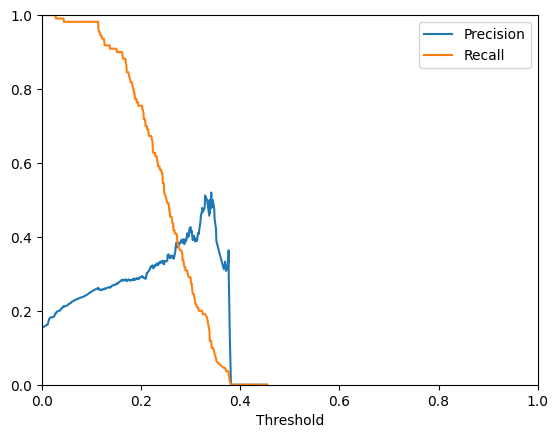

In [18]:
precisions, recalls, thresholds = precision_recall_curve(y, y_probs)
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.xlim([0,1 ]) 
plt.ylim([0, 1])
plt.legend()
plt.show()